In [10]:
#Importing libraries
import pandas as pd

In [11]:
#Reading the dataset
data=pd.read_csv("datanew.csv")

In [12]:
#Data Understanding
print(data.head())
print(data.describe())
print(data.info())
print(data.columns)

                  date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
0  2014-05-02 00:00:00   313000.0       3.0       1.50         1340      7912   
1  2014-05-02 00:00:00  2384000.0       5.0       2.50         3650      9050   
2  2014-05-02 00:00:00   342000.0       3.0       2.00         1930     11947   
3  2014-05-02 00:00:00   420000.0       3.0       2.25         2000      8030   
4  2014-05-02 00:00:00   550000.0       4.0       2.50         1940     10500   

   floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0     1.5           0     0          3        1340              0      1955   
1     2.0           0     4          5        3370            280      1921   
2     1.0           0     0          4        1930              0      1966   
3     1.0           0     0          4        1000           1000      1963   
4     1.0           0     0          4        1140            800      1976   

   yr_renovated                    str

In [13]:
# Remove missing values
data = data.dropna()

# remove top 1% extreme prices that confuse the model
data = data[data['price'] < data['price'].quantile(0.99)]

# Drop ALL problematic columns BEFORE encoding
data = data.drop([
    "id",
    "date",
    "street",
    "city",
    "statezip",
    "country"
], axis=1, errors='ignore')

In [14]:
print(data.shape)
print(data.dtypes)

(4554, 13)
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
dtype: object


In [15]:
data=data.loc[:,~data.columns.str.contains("statezip")]

In [16]:
print(data.shape)

(4554, 13)


In [17]:
features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated"
]
x = data[features]
y = data["price"]

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

x_train,x_test,y_train,y_test= train_test_split(
    x,y,test_size=0.2,random_state=42
)
model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [20]:
from sklearn.metrics import r2_score

y_pred= model.predict(x_test)
print("R2:",r2_score(y_test,y_pred))

R2: 0.4983198666801656


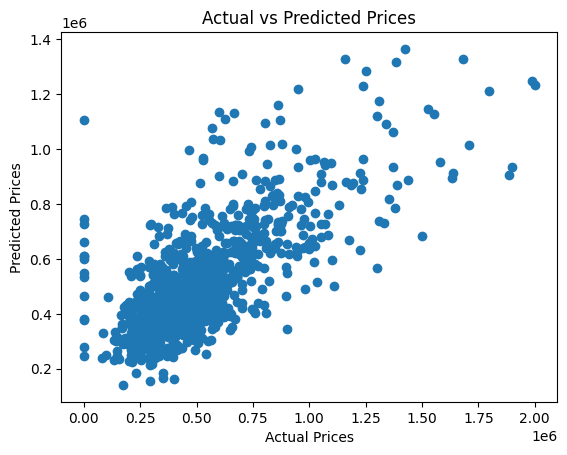

In [21]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

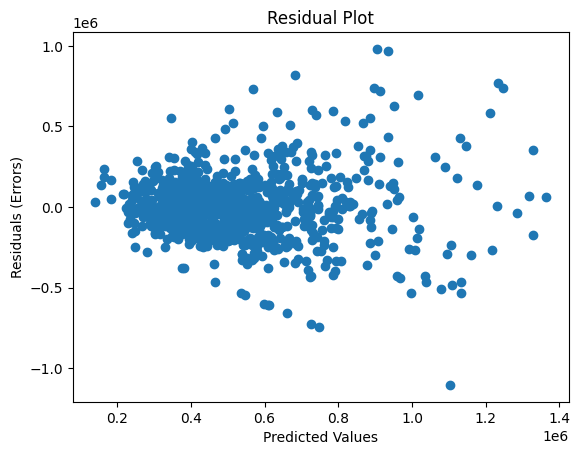

In [22]:
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Errors)")
plt.title("Residual Plot")
plt.show()

In [23]:
import pandas as pd

coefficients = model.coef_
feature_names = x.columns

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": coefficients
})

print(coef_df.sort_values(by="Importance", ascending=False))

          Feature    Importance
4          floors  74922.578918
6            view  53224.159821
1       bathrooms  42989.384844
7       condition  29866.279193
2     sqft_living    132.369576
8      sqft_above     76.434093
9   sqft_basement     55.935484
11   yr_renovated      4.273932
3        sqft_lot     -0.366040
10       yr_built  -2256.175344
0        bedrooms -34195.611399
5      waterfront -70936.619255
